# MRI Dementia Retraining - MobileNetV2, 3 Classes

Target classes:

```python
['NonDemented', 'MildOrVeryMildDemented', 'ModerateDemented']
```

Mapping from the 4-folder dataset:

```python
NonDemented       -> NonDemented
VeryMildDemented  -> MildOrVeryMildDemented
MildDemented      -> MildOrVeryMildDemented
ModerateDemented  -> ModerateDemented
```

Important: MobileNetV2 uses `tf.keras.applications.mobilenet_v2.preprocess_input`, so do **not** divide images by `255` in the dataset pipeline.

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Upload Or Mount Dataset

Upload your dataset zip to Colab or mount Google Drive. The expected folder is:

```text
combined_dataset_plus_oasis_disc1_disc2_axial_coronal_180_shuffled/
  MildDemented/
  ModerateDemented/
  NonDemented/
  VeryMildDemented/
```

In [2]:
# Optional: mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
ZIP_PATH = "/content/drive/MyDrive/combined_dataset_plus_oasis_disc1_disc2_axial_coronal_180_shuffled.zip"
EXTRACT_DIR = "/content/mri_dataset"

if os.path.exists(ZIP_PATH):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extracted to:", EXTRACT_DIR)
else:
    print("Zip not found. If using Google Drive, set DATASET_DIR manually below.")

Extracted to: /content/mri_dataset


In [4]:
DATASET_DIR = "/content/mri_dataset/combined_dataset_plus_oasis_disc1_disc2_axial_coronal_180_shuffled"

# Google Drive example:
# DATASET_DIR = "/content/drive/MyDrive/combined_dataset_plus_oasis_disc1_disc2_axial_coronal_180_shuffled"

source_class_names = [
    "MildDemented",
    "ModerateDemented",
    "NonDemented",
    "VeryMildDemented",
]

class_names = [
    "NonDemented",
    "MildOrVeryMildDemented",
    "ModerateDemented",
]

source_to_target_class = {
    "NonDemented": "NonDemented",
    "VeryMildDemented": "MildOrVeryMildDemented",
    "MildDemented": "MildOrVeryMildDemented",
    "ModerateDemented": "ModerateDemented",
}

target_class_to_index = {name: i for i, name in enumerate(class_names)}

dataset_path = Path(DATASET_DIR)
print("Dataset path exists:", dataset_path.exists())
print("Target class order:", class_names)
print("Source folder counts:")

for cls in source_class_names:
    class_dir = dataset_path / cls
    print(cls, len(list(class_dir.glob("*.png"))) if class_dir.exists() else "missing")

Dataset path exists: True
Target class order: ['NonDemented', 'MildOrVeryMildDemented', 'ModerateDemented']
Source folder counts:
MildDemented 3235
ModerateDemented 2572
NonDemented 4812
VeryMildDemented 3752


## Collect Image Paths

In [5]:
image_paths = []
labels = []
source_labels = []

for source_cls in source_class_names:
    class_dir = dataset_path / source_cls
    target_cls = source_to_target_class[source_cls]
    target_idx = target_class_to_index[target_cls]

    for p in class_dir.glob("*"):
        if p.suffix.lower() in [".png", ".jpg", ".jpeg"] and not p.name.startswith("._"):
            image_paths.append(str(p))
            labels.append(target_idx)
            source_labels.append(source_cls)

image_paths = np.array(image_paths)
labels = np.array(labels)
source_labels = np.array(source_labels)

print("Total images:", len(image_paths))
print("3-class target order:", class_names)

print("Target class counts:")
for i, cls in enumerate(class_names):
    print(cls, int(np.sum(labels == i)))

print("\nOriginal source folder counts included:")
for cls in source_class_names:
    print(cls, int(np.sum(source_labels == cls)))

Total images: 14371
3-class target order: ['NonDemented', 'MildOrVeryMildDemented', 'ModerateDemented']
Target class counts:
NonDemented 4812
MildOrVeryMildDemented 6987
ModerateDemented 2572

Original source folder counts included:
MildDemented 3235
ModerateDemented 2572
NonDemented 4812
VeryMildDemented 3752


## Train / Validation Split

This uses the same stratified image-level split style as the ~82% run.

In [6]:
train_paths, val_paths, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))

for i, cls in enumerate(class_names):
    print(cls, "train:", int(np.sum(y_train == i)), "val:", int(np.sum(y_val == i)))

Train: 11496
Validation: 2875
NonDemented train: 3849 val: 963
MildOrVeryMildDemented train: 5589 val: 1398
ModerateDemented train: 2058 val: 514


## Class Weights

In [7]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=y_train
)

class_weights = dict(enumerate(class_weights_array))
print(class_weights)

{0: np.float64(0.9955832683813978), 1: np.float64(0.6856324923957774), 2: np.float64(1.8620019436345967)}


## Build `tf.data` Datasets

Images are loaded as RGB because MobileNetV2 was pretrained on RGB ImageNet images. Keep pixels in `0..255`; MobileNet preprocessing happens inside the model.

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, y_train))
train_ds = train_ds.shuffle(buffer_size=len(train_paths), seed=42)
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, y_val))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

## Data Augmentation - Original Baseline

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.10),
])

## Build MobileNetV2 Model - Original Baseline

In [10]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.35)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train Classifier Head

In [11]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_mobilenet_mri_3class.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.6717 - loss: 0.5858 - val_accuracy: 0.6553 - val_loss: 0.5869 - learning_rate: 0.0010
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - accuracy: 0.7355 - loss: 0.4563 - val_accuracy: 0.7037 - val_loss: 0.5890 - learning_rate: 0.0010
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.7430 - loss: 0.4367 - val_accuracy: 0.6998 - val_loss: 0.4861 - learning_rate: 0.0010
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.7501 - loss: 0.4197 - val_accuracy: 0.7398 - val_loss: 0.5148 - learning_rate: 0.0010
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 40s 76ms/step - accuracy: 0.7673 - loss: 0.4031 - val_accuracy: 0.7297 - val_loss: 0.5589 - learning_rate: 0.0010
Epoch 6/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.7684 - loss: 0.3860 - val_accuracy: 0.7263 - val_loss: 0.5013 - learning_rate: 0.0010
Epoch 7/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.7762 - l

## Fine-Tune Top MobileNet Layers

In [12]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 57s 121ms/step - accuracy: 0.7200 - loss: 0.8094 - val_accuracy: 0.7798 - val_loss: 0.4550 - learning_rate: 1.0000e-05
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 37s 102ms/step - accuracy: 0.7542 - loss: 0.4590 - val_accuracy: 0.7899 - val_loss: 0.4232 - learning_rate: 1.0000e-05
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.7719 - loss: 0.3881 - val_accuracy: 0.8073 - val_loss: 0.3819 - learning_rate: 1.0000e-05
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.7736 - loss: 0.3607 - val_accuracy: 0.8191 - val_loss: 0.3476 - learning_rate: 1.0000e-05
Epoch 5/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.7914 - loss: 0.3262 - val_accuracy: 0.8230 - val_loss: 0.3376 - learning_rate: 1.0000e-05
Epoch 6/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 36s 101ms/step - accuracy: 0.7999 - loss: 0.3191 - val_accuracy: 0.8181 - val_loss: 0.3432 - learning_rate: 1.0000e-05
Epoch 7/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 41s 10

## Evaluate Best Model

In [13]:
best_model = tf.keras.models.load_model("best_mobilenet_mri_3class.keras")

val_loss, val_acc = best_model.evaluate(val_ds)
print("Validation loss:", val_loss)
print("Validation accuracy:", val_acc)

90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.8400 - loss: 0.3209
Validation loss: 0.32090505957603455
Validation accuracy: 0.8399999737739563


In [14]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = best_model.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

print("Classification report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

Confusion matrix:
[[ 854  109    0]
 [ 350 1047    1]
 [   0    0  514]]
Classification report:
                        precision    recall  f1-score   support

           NonDemented       0.71      0.89      0.79       963
MildOrVeryMildDemented       0.91      0.75      0.82      1398
      ModerateDemented       1.00      1.00      1.00       514

              accuracy                           0.84      2875
             macro avg       0.87      0.88      0.87      2875
          weighted avg       0.86      0.84      0.84      2875



## Plot Training Curves

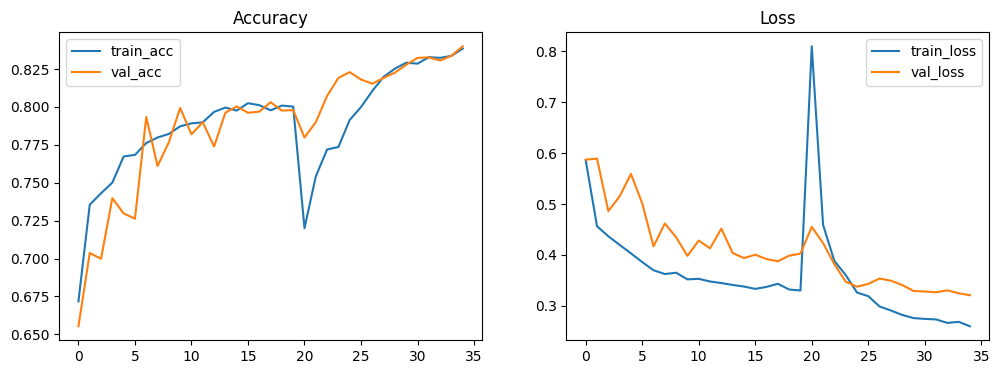

In [15]:
def plot_history(histories):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for h in histories:
        acc += h.history.get("accuracy", [])
        val_acc += h.history.get("val_accuracy", [])
        loss += h.history.get("loss", [])
        val_loss += h.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(acc, label="train_acc")
    plt.plot(val_acc, label="val_acc")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.legend()
    plt.title("Loss")

    plt.show()

plot_history([history, history_finetune])

## Save Final Model

In [16]:
best_model.save("mobilenet_mri_dementia_3class_final.keras")
print("Saved: mobilenet_mri_dementia_3class_final.keras")

Saved: mobilenet_mri_dementia_3class_final.keras
